# Choice of couplings in flow matching

This notebook demonstrates flow matching with three different choices of couplings between the source $\mu_0$ and target $\mu_1$.

* **Independent coupling (I-FM)**: $(x_0, x_1)$ is sampled from the independent coupling, i.e. $\pi = \mu_0 \otimes \mu_1$, see e.g. Lipman et al., Albergo et al.
* **Minibatch OT coupling (OT-FM)**: $(x_0, x_1)$ are paired using mini-batch OT, see e.g. Pooladian et al., Tong et al.
* **Semi-discrete OT coupling (SD-FM)**: $(x_0, x_1)$ are paired using semidiscrete OT, introduced in Mousavi et al.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Use GPU 0 only

In [2]:
# Basic imports
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.tree_util as jtu
import jax.numpy as jnp
import jax.random as jr
import flax.linen as nn
import optax
# For loading images
from PIL import Image, ImageOps
# OTT tools
from ott.tools import unreg
from ott.geometry import costs, pointcloud
from ott.geometry import semidiscrete_pointcloud as sdpc
from ott.problems.linear import semidiscrete_linear_problem as sdlp
from ott.solvers import linear
from ott.solvers.linear import semidiscrete
from ott.tools import plot
from diffrax import diffeqsolve, ODETerm, SaveAt, Dopri5
import pickle
from tqdm import tqdm
import matplotlib.animation as mpa
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython import display
# 
TRAIN=False # Set to True to train models, otherwise load existing weights
WEIGHTS_DIR="weights"

## Load image and convert to pointcloud

In [10]:
# download penrose triangle image
!wget "https://upload.wikimedia.org/wikipedia/commons/6/6e/Pentriangle.png"

--2026-03-05 21:27:08--  https://upload.wikimedia.org/wikipedia/commons/6/6e/Pentriangle.png
Resolving upload.wikimedia.org (upload.wikimedia.org)... 103.102.166.240, 2001:df2:e500:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|103.102.166.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4784 (4.7K) [image/png]
Saving to: ‘Pentriangle.png.2’

Pentriangle.png.2   100%[===================>]   4.67K  --.-KB/s    in 0s      

2026-03-05 21:27:09 (69.5 MB/s) - ‘Pentriangle.png.2’ saved [4784/4784]



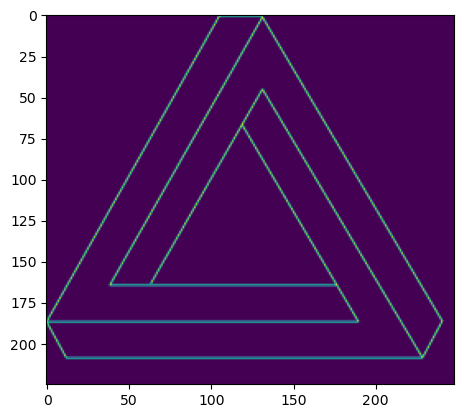

In [11]:
img = ImageOps.grayscale(Image.open("Pentriangle.png"))
img = ImageOps.invert(img)
img = np.array(img)
plt.imshow(img)

# Extract image as point cloud
w, h = img.shape
x_grid, y_grid = np.meshgrid(range(w), range(h), indexing="ij")
xy_grid = np.vstack([x_grid.reshape(-1) / h, y_grid.reshape(-1) / w]).T
probs = img.reshape(-1)
probs = probs / probs.sum()
xy_grid = xy_grid[probs > 0]
probs = probs[probs > 0]

## Define simple flow model and training loop

In [12]:
# Define a simple flow model
class MLP(nn.Module):
    hidden: list[int]
    @nn.compact
    def __call__(self, t: jax.Array, x:jax.Array, n_freqs: int=32):
        while t.ndim < x.ndim:
            t = t[..., None]
        # time embedding
        t = jnp.concatenate(
            [jnp.sin(2**i * jnp.pi * t) for i in range(n_freqs)]
            + [jnp.cos(2**i * jnp.pi * t) for i in range(n_freqs)],
            axis=-1,
        )
        x = jnp.concatenate([t, x], axis=-1)
        for feat in self.hidden[:-1]:
            x = nn.relu(nn.Dense(feat)(x))
        x = nn.Dense(self.hidden[-1])(x)
        return x
# FM training loop
@jax.jit
def step(v_params, key: jax.Array, x0: jax.Array, x1: jax.Array):
    def loss_fn(v_params, t: jax.Array, x0: jax.Array, x1: jax.Array):
        xt = (1 - t) * x0 + t * x1
        v_t = v.apply(v_params, t, xt)
        v_target = x1 - x0
        loss = jnp.mean((v_t - v_target) ** 2)
        return loss
    grad_fn = jax.value_and_grad(loss_fn)
    key, subkey = jr.split(key)
    t = jr.uniform(subkey, shape=(x0.shape[0], 1), minval=0.0, maxval=1.0)
    loss, grads = grad_fn(v_params, t, x0, x1)
    return loss, grads

In [14]:
key = jr.key(42)
p = jax.device_put(probs)
x_target = jax.device_put(xy_grid)
# normalize training data 
x_target = x_target - x_target.mean(axis=0)
x_target = x_target / x_target.std(axis=0)

## Train semidiscrete potential

In [15]:
geom = sdpc.SemidiscretePointCloud(
    sampler=jr.normal, y=x_target, epsilon=0.0, cost_fn=costs.SqEuclidean()
)
error_eval_every = 5000
def print_callback(state: semidiscrete.SemidiscreteState) -> None:
    it = state.it.item()
    if it > 0 and it % error_eval_every == 0:
        loss = state.errors[it // error_eval_every - 1].item()
        print(f"It. {it:5d}, marginal χ2 error={loss:.4f}")
@jax.jit
def solve_semidiscrete(
    rng: jax.Array, geom: sdpc.SemidiscretePointCloud
) -> semidiscrete.SemidiscreteOutput:
    prob = sdlp.SemidiscreteLinearProblem(geom)
    solver = semidiscrete.SemidiscreteSolver(
        num_iterations=25_000,
        batch_size=128,
        optimizer=optax.adagrad(learning_rate=0.001),
        error_eval_every=error_eval_every,
        callback=print_callback,
    )
    return solver(rng, prob)

sd_sol = solve_semidiscrete(key, geom)

It.  5000, marginal χ2 error=0.3213
It. 10000, marginal χ2 error=0.2215
It. 15000, marginal χ2 error=0.3462
It. 20000, marginal χ2 error=0.1218
It. 25000, marginal χ2 error=0.1218


## Visualise semidiscrete potential

The optimal semidiscrete potential $g$ is defined on the support of $\mu_1$, i.e. `x_target`

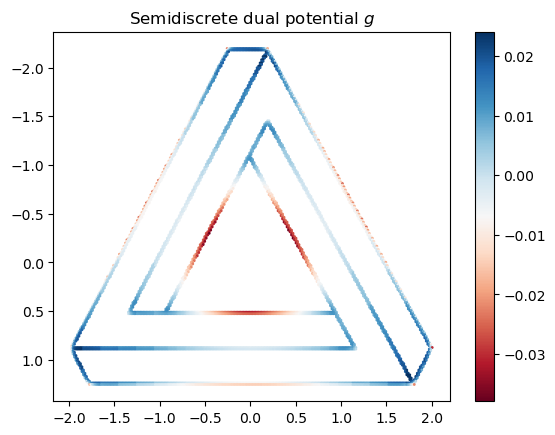

In [17]:
plt.scatter(x_target[:, 1], x_target[:, 0], c = sd_sol.g, cmap = 'RdBu', s = 1)
plt.colorbar()
plt.title("Semidiscrete dual potential $g$")
plt.gca().invert_yaxis()

## Train flow matching models

Here we train three FM models with different choices of coupling.

In [22]:
@jtu.Partial(jax.jit, static_argnames=("what", ))
def _pair(x0: jax.Array, x1: jax.Array, aux, what: str):
    if what == "semidiscrete":
        g = aux
        geom = pointcloud.PointCloud(
            x0, x1, cost_fn=costs.SqEuclidean()
        )
        idx = jnp.argmax(g[None, :] - geom.cost_matrix, axis=-1)
        return x0, x1[idx, :]
    elif what == "minibatch_ot":
        geom = pointcloud.PointCloud(
            x0, x1, cost_fn=costs.SqEuclidean()
        )
        sol = unreg.hungarian(geom)
        x0 = x0[sol[1].paired_indices[0]]
        x1 = x1[sol[1].paired_indices[1]]
        return x0, x1
    else:
        return x0, x1

methods = ["semidiscrete", "minibatch_ot", "ifm"]
v = MLP(hidden=[128, 128, 128, 128, 2])
v_params = {}
for what in methods:
    key, subkey = jr.split(key, 2)
    v_params[what] = v.init(subkey, jnp.ones(1), jnp.ones((1, 2)))

def train(v, v_params, what:str, key: jax.Array, lr: float = 3e-4, num_iters:int=100_000, print_iter:int=25_000, batch_size:int=128):
    opt = optax.adam(lr)
    opt_state = opt.init(v_params)
    for it in tqdm(range(num_iters)):
        key, subkey1, subkey2, subkey3 = jr.split(key, 4)
        x0 = jr.normal(subkey1, shape=(batch_size, 2))
        if what == "semidiscrete":
            x1 = x_target
            x0, x1 = _pair(x0, x1, what=what, aux=sd_sol.g)
        else:
            x1 = x_target[jr.choice(subkey2, len(p), p=p, shape=(batch_size,))]
            x0, x1 = _pair(x0, x1, what=what, aux=None)
        loss, grads = step(v_params, subkey3, x0, x1)
        updates, opt_state = opt.update(grads, opt_state)
        v_params = optax.apply_updates(v_params, updates)
        if it % print_iter == 0:
            print(f"loss = {loss}")
    return v_params

if TRAIN:
    for what in methods:
        key, subkey = jr.split(key, 2)
        v_params[what]=train(v, v_params[what], what, subkey)
        print(f"Saving weights for model={what}")
        with open(os.path.join(WEIGHTS_DIR, f"params_{what}.pkl"), "wb") as f:
                pickle.dump(v_params[what], f)
else:
    for what in methods:
        print(f"Loading weights for model={what}")
        with open(os.path.join(WEIGHTS_DIR, f"params_{what}.pkl"), "rb") as f:
            v_params[what] = pickle.load(f)

Loading weights for model=semidiscrete
Loading weights for model=minibatch_ot
Loading weights for model=ifm


## Sample trajectories from trained model

In [27]:
# sample from trained model
def f(t, x, args):
    v_params = args
    t = jnp.repeat(t, x.shape[0], axis=0)
    v_t = v.apply(v_params, t, x)
    return v_t

term = ODETerm(f)
solver = Dopri5()
N = 10_000
y0 = jr.normal(key, shape=(N, 2))
sols = {}
for what in methods:
    sols[what] = diffeqsolve(
        term,
        solver,
        t0=0.0,
        t1=1.0,
        dt0=0.01,
        y0=y0,
        args=v_params[what],
        saveat=SaveAt(ts=jnp.linspace(0, 1, 190), t1=False),
    )

In [28]:
titles = {"semidiscrete" : "SD-FM",
          "minibatch_ot" : f"OT-FM, $B$ = 128",
          "ifm" : "I-FM"}

In [29]:
def to_video(ani: mpa.FuncAnimation) -> None:
    display.display(display.HTML(ani.to_html5_video()))
fig, axs = plt.subplots(1, len(methods), figsize=(10, 3))
i = -1
scs = [ax.scatter(sols[what].ys[i, :, 1], sols[what].ys[i, :, 0], alpha=0.3, color="k", s=1) for (ax, what) in zip(axs, methods)]
for (ax, what) in zip(axs, methods):
    ax.axis("off")
    ax.margins(0)
    ax.figure.tight_layout(pad=0)
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.invert_yaxis()
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(titles[what])
def update(i):
    for (j, m) in enumerate(methods):
        pts = sols[m].ys[i, :, ::-1]
        scs[j].set_offsets(pts)
    return None
for i in range(len(sols[methods[0]].ts)):
    update(i)
ani = FuncAnimation(fig, update, frames=len(sols[methods[0]].ts), interval=50)
plt.close()

In [30]:
to_video(ani)